# Deep Learning Volatility: a Neural Network Approach to the Rough Bergomi Model

**Tom Ducard, Quentin Latil, Anastasiia Tolstineva**  
**ENSAE, Machine Learning in Finance, April 2026**

*Project report based on Horvath, B., Muguruza, A., Tomas, M. (2019), ["Deep learning volatility: A deep neural network perspective on pricing and calibration in (rough) volatility models"](https://arxiv.org/abs/1901.09647).*

---

This notebook constitutes our project report. It combines theoretical background, numerical experiments, and discussion of results in a single document. The structure follows the paper's logic, with two extensions of our own. Section 6 studies the impact of changing the strike and maturity grid. Section 7 addresses a question that is natural from an industrial deployment perspective: can the same neural architecture serve different asset classes by simply retraining on a different parameter distribution?

All simulation, training, and evaluation code lives in the `src/` package. The notebook orchestrates, visualizes and comments. Source is available on GitHub: [Quenitn/Rough-Bergomi-Deep-Learning](https://github.com/Quenitn/Rough-Bergomi-Deep-Learning).

## 1. Introduction: the Calibration Bottleneck in Rough Volatility Modelling

### 1.1 The modelling dilemma

Modelling the implied volatility surface is one of the central challenges of quantitative finance. For risk management, pricing, and hedging, a model's ability to reproduce the smile observed in the market is essential. Practitioners traditionally rely on stochastic volatility models such as Heston or SABR, which admit semi-analytical formulas or fast Fourier-based pricing. These classical frameworks have two virtues: tractability and acceptable empirical fit on middle maturities. They struggle however with the short-maturity skew of equity indices, which is extremely steep and essentially impossible to reproduce with diffusive volatility.

This empirical shortcoming motivated a line of work initiated by Gatheral, Jaisson and Rosenbaum (2018) and Bayer, Friz and Gatheral (2016), showing that the volatility of equity indices is well described by a fractional Brownian motion with a Hurst exponent $H < 0.5$, giving rise to *rough volatility models*. The reduction in the number of parameters combined with the quality of the fit on the whole surface is striking. For SPX data, $H$ is typically estimated between $0.05$ and $0.15$.

The downside is severe. Rough volatility processes are not semimartingales and not Markovian. PDE methods, Fourier pricing, and most closed-form techniques break down. Each option price has to be computed by Monte Carlo simulation, with costs of several hundred milliseconds per full surface. Calibration, which by definition requires thousands of such evaluations, becomes a technological bottleneck. This has long been cited as the main reason rough volatility models have not been widely adopted in production despite their theoretical appeal.

### 1.2 The deep learning approach

Horvath, Muguruza and Tomas (2019) propose a pragmatic solution. They decouple pricing and calibration into two distinct phases:

1. **Offline phase**: a neural network is trained on synthetic data to approximate the map from model parameters to the full implied volatility surface.  
2. **Online phase**: the trained network replaces the Monte Carlo simulator in the calibration loop. Because the network is a composition of differentiable functions, gradient-based optimizers can be used directly.

The central claim is that the network evaluates a full surface in microseconds instead of hundreds of milliseconds, yielding a speedup of roughly four orders of magnitude, while maintaining accuracy comparable to the Monte Carlo noise floor. This makes rough volatility models calibratable in real time.

### 1.3 Scope of this report

We reproduced the main numerical claims of the paper on our own implementation of the rough Bergomi simulator and the neural network approximator (sections 3 to 5). Section 5bis adds a learning curve analysis that illustrates how dataset size drives accuracy. Section 6 studies the impact of changing the strike and maturity grid, which is relevant when a desk works on a specific part of the surface (short-dated options, for instance). Section 7 changes the market regime through the parameter distribution, in order to answer a concrete question: can the same architecture serve different asset classes by simply retraining? Section 8 concludes and lists the main limitations of our implementation along with directions for future work.

## 2. The Rough Bergomi Model

### 2.1 Dynamics under the pricing measure

The rough Bergomi model, introduced by Bayer, Friz and Gatheral (2016), specifies the log-price $X_t = \log(S_t / S_0)$ and the instantaneous variance $V_t$ under the pricing measure $\mathbb{Q}$ as:

$$
\begin{aligned}
dX_t &= -\tfrac{1}{2} V_t \, dt + \sqrt{V_t} \, dW_t, \qquad X_0 = 0 \\[6pt]
V_t &= \xi_0(t) \, \exp\!\left( \eta \sqrt{2H} \int_0^t (t - s)^{H - \tfrac{1}{2}} \, dZ_s \;-\; \tfrac{1}{2} \eta^2 \, t^{2H} \right)
\end{aligned}
$$

The two driving Brownian motions $W$ and $Z$ are correlated with correlation $\rho \in [-1, 1]$. The parameters are:

- $H \in (0, 1/2)$, the **Hurst exponent**. Controls the roughness of the volatility path. Empirical estimates on equity indices put $H$ in $[0.05, 0.15]$.
- $\eta > 0$ (sometimes written $\nu$), the **volatility of volatility**. Controls the amplitude of fluctuations of $V_t$.
- $\rho \in [-1, 1]$, the leverage effect. Strongly negative for equity indices.
- $\xi_0(\cdot)$, the **initial forward variance curve**. Approximated in our implementation by a piecewise constant function on the maturity grid. This gives 8 additional parameters $\xi_1, \dots, \xi_8$.

The parameter vector is therefore $\theta = (\xi_1, \dots, \xi_8, \eta, \rho, H) \in \mathbb{R}^{11}$.

### 2.2 Why is $H < 0.5$ the central innovation

The Hurst exponent is not a free modelling choice. The empirical finding of Gatheral, Jaisson and Rosenbaum (2018), confirmed since on thousands of equity indices and individual stocks, is that log-volatility scales like a fractional Brownian motion with $H$ around $0.1$. This was established by regressing the logarithm of increments of the realized variance on the logarithm of the lag: the regression slope estimates $H$, and gives consistent values far below the diffusive benchmark $H = 0.5$.

Why does this matter for pricing? In any classical diffusive model (Heston, Bergomi, SABR), the ATM skew decays as $T^{-1/2}$ for short maturities. Rough volatility with $H < 0.5$ produces an ATM skew that decays as $T^{H - 1/2}$, which for $H = 0.1$ means a much slower decay (close to $T^{-0.4}$). This matches the empirically observed "power law" steepness of the SPX short-dated smile, which no diffusive model can reproduce without pathological parameter values. In other words: $H < 0.5$ is not a modelling preference, it is a statistical fact that classical models cannot fit and rough models can.

### 2.3 Why the model is hard to price

The convolution with the singular kernel $(t - s)^{H - 1/2}$ is both the source of the model's empirical power and the reason it is numerically painful. Because the driving process is not a semimartingale, Itô calculus does not apply in the standard form. Because it is not Markovian, the pair $(X_t, V_t)$ does not satisfy a PDE. Fourier pricing is ruled out too: the characteristic function is not known in closed form. The only reliable pricing tool is Monte Carlo simulation.

We simulate the Volterra integral using a hybrid scheme inspired by Bennedsen, Lunde and Pakkanen (2017). The integral is discretized on a time grid of $n$ steps with step size $\Delta t$. On the most recent interval $[t_{k-1}, t_k]$, we sample exactly the joint Gaussian pair $(W_{t_k} - W_{t_{k-1}}, \int_{t_{k-1}}^{t_k} (t_k - s)^{H - 1/2} dW_s)$ via a $2 \times 2$ Cholesky decomposition of the exact covariance matrix. On older intervals, we use a Riemann approximation with weights $b_k = (k^{\alpha + 1} - (k-1)^{\alpha + 1}) / (\alpha + 1) \cdot \Delta t^\alpha$ where $\alpha = H - 1/2$. This is the BLP scheme with $\kappa = 1$ (exact on the most recent step only). The full BLP scheme also simulates exactly the first few steps near $t = 0$, which we did not implement for time reasons. Residual discretization bias is compensated by a spot martingale control variate $S_T \leftarrow S_T \cdot S_0 / \bar{S}_T$ applied after simulation, following Section 4.1.1 of the paper.

### 2.4 From pricing map to learning problem

For a fixed grid of strikes $\{k_j\}_{j=1..n}$ and maturities $\{T_i\}_{i=1..m}$, the model defines a map
$$
\Phi : \Theta \longrightarrow \mathbb{R}^{m \times n}, \qquad \theta \mapsto \sigma_{BS}^{M(\theta)}(T_i, k_j)
$$
that sends a parameter vector to the grid of Black-Scholes implied volatilities. This map is deterministic, smooth in $\theta$, and expensive to evaluate: each evaluation requires a full Monte Carlo simulation.

The central idea of Horvath, Muguruza and Tomas is to decouple the pricing map from the calibration loop. Classical calibration solves
$$\hat{\theta} = \arg\min_{\theta \in \Theta} \delta(P^{MC}(\theta), P^{MKT})$$
where each evaluation of $P^{MC}$ requires a Monte Carlo simulation. The paper replaces this by a two-step approach:

- **Offline**: learn $F^{NN}(\theta) \approx \Phi(\theta)$ once, by supervised training on synthetic data.
- **Online**: solve $\hat{\theta} = \arg\min_{\theta \in \Theta} \delta(F^{NN}(\theta), P^{MKT})$ with gradient-based optimizers, using backpropagation through the network to compute gradients.

The key observation is that the offline cost is paid once and amortized over every subsequent market calibration (typically hundreds per day in production). The online cost drops from "seconds of Monte Carlo" to "microseconds of neural network", which is the four orders of magnitude speedup the paper reports and that we validate in Section 5.

### 2.5 Why implied vols and not prices, why the whole surface and not one point

Two design choices deserve discussion because they are central to how the network is trained.

**Implied volatilities rather than raw prices.** Implied vols live in a bounded range (roughly $[0.01, 2]$ for reasonable markets), vary smoothly across $(T, K)$, and are more uniform across the parameter space than prices, which explode in the money and vanish out of the money. Raw prices span several orders of magnitude across a single surface, which makes them a harder learning target. Implied vols are also closer to the quantity traders actually reason about, so the natural output space of the learning problem.

**Whole surface at once, not one point at a time.** A natural alternative would be to take $(\theta, T, K)$ as input and return a single implied vol $\sigma(\theta, T, K)$. The paper argues against this pointwise formulation for three reasons. First, pricing a surface of 88 points would require 88 forward passes, losing most of the speed advantage. Second, the pointwise formulation does not exploit the natural smoothness of the surface in $(T, K)$ space: the 88 outputs of the image-based network are constrained jointly by the training loss, which regularizes the solution along strike and maturity axes. Third, the pointwise formulation converges empirically to a worse solution, which the authors attribute to a lower injectivity of the training map (two distinct parameter sets are less likely to produce the same surface than the same single implied vol). We follow the image-based approach throughout.

In [1]:
# Imports
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm

# Project modules
from src.model.rough_bergomi import RoughBergomi
from src.simulation.hybrid_scheme import HybridScheme
from src.nn.model import VolatilityNet
from src.nn.training import train_model, predict_denormalized, get_device
from src.utils.pipeline import generate_dataset, compute_surface_from_prices
from src.utils.normalization import normalize_inputs, normalize_outputs
from src.utils.black_scholes import implied_vol
import plot_results as pr

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = get_device()
print(f"Device: {DEVICE}")

# Plot style
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.3, "font.size": 10,
})

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# -----------------------------------------------------------
# Run parameters. Small values are used for a quick test run.
# Final run values are commented on the right.
# -----------------------------------------------------------
# Baseline (sections 3-5)
N_SAMPLES_BASELINE = 20000  
N_PATHS_BASELINE   = 30000
# Experiments (sections 6 and 7)
N_SAMPLES_EXP      = 20000
N_PATHS_EXP        = 30000
N_HV_TEST          = 100
N_STEPS            = 100

# Threshold to exclude pathologically low implied vols from relative error
MASK_THRESHOLD = 5e-2


Device: mps


### 2.4 Visualizing roughness

Before training anything, it helps to build intuition on what the Hurst exponent actually does to a volatility path. We simulate four variance paths driven by the exact same Brownian noise, varying only the Hurst parameter. Everything else, including the specific realization of the Brownian motion, is identical.

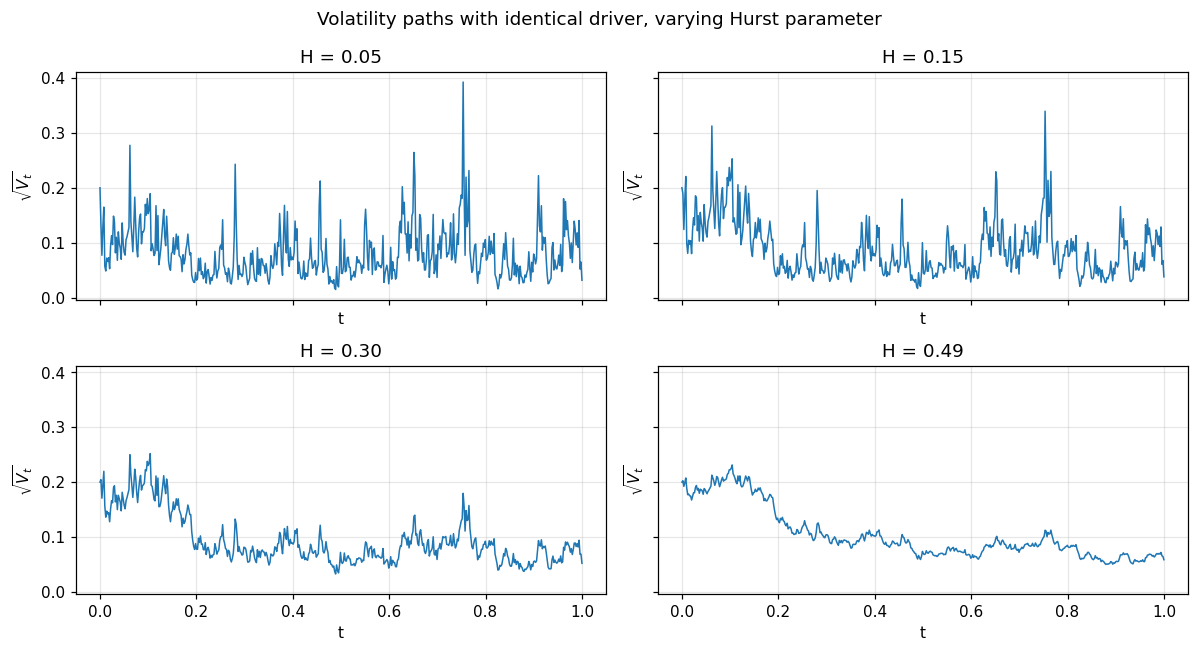

In [2]:
# Simulate variance paths with identical noise, varying H
T_max = 1.0
n_steps_viz = 500
dt = T_max / n_steps_viz
t_grid = np.linspace(0, T_max, n_steps_viz)

rng = np.random.default_rng(SEED)
dW = rng.normal(0, np.sqrt(dt), n_steps_viz)

def volterra_path(H, dW, dt):
    alpha = H - 0.5
    k = np.arange(1, len(dW) + 1)
    kernel = (k**(alpha + 1) - (k - 1)**(alpha + 1)) / (alpha + 1) * dt**alpha
    path = np.zeros(len(dW))
    for t in range(1, len(dW)):
        path[t] = np.dot(dW[:t], kernel[:t][::-1])
    return path

H_values = [0.05, 0.15, 0.30, 0.49]
eta, xi0 = 2.0, 0.04

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)
for ax, H in zip(axes.flat, H_values):
    volt = volterra_path(H, dW, dt)
    V = xi0 * np.exp(eta * np.sqrt(2 * H) * volt
                     - 0.5 * eta**2 * t_grid**(2 * H))
    ax.plot(t_grid, np.sqrt(V), lw=1.0)
    ax.set_title(f"H = {H:.2f}")
    ax.set_ylabel(r"$\sqrt{V_t}$")
    ax.set_xlabel("t")
fig.suptitle("Volatility paths with identical driver, varying Hurst parameter")
plt.tight_layout()
plt.savefig("figures/variance_paths_by_H.png", bbox_inches="tight")
plt.show()

For $H = 0.05$ the path exhibits the characteristic jagged structure of rough volatility, with short-range oscillations of large amplitude that no smooth stochastic volatility model can reproduce. For $H = 0.49$ the path is visibly closer to a standard Bergomi path, which is itself already quite oscillatory but remains a semimartingale. The intermediate values $H = 0.15$ and $H = 0.30$ show the progressive transition. Qualitatively, the rougher the path, the steeper the resulting short-maturity smile on the implied volatility surface, as observed on equity indices.

## 3. Data Generation

### 3.1 Sampling strategy

The training set consists of pairs $(\theta_i, \Sigma_i)$ where $\theta_i$ is sampled uniformly over the admissible parameter domain $\Theta$ and $\Sigma_i$ is the implied volatility surface computed by Monte Carlo under the rough Bergomi model with parameters $\theta_i$. The domain we use for the baseline regime, matching the paper, is:

| Parameter | Range |
|---|---|
| $\xi_i$ (each of the 8 values) | $[0.01, 0.16]$ |
| $\eta$ | $[0.5, 4.0]$ |
| $\rho$ | $[-0.95, -0.1]$ |
| $H$ | $[0.025, 0.5]$ |

The output is a $8 \times 11$ grid of Black-Scholes implied volatilities, with maturities $\{0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0\}$ years and strikes $\{0.5, 0.6, \dots, 1.5\}$ (expressed as ratios to spot). Flattened, each surface is a 88-dimensional vector.

Uniform sampling on parameters that naturally live on a multiplicative scale (notably $\xi_i$ and $\eta$) is debatable. A log-uniform sampling would be more faithful to the multiplicative nature of variance quantities and would improve coverage of low-volatility regimes, which are underrepresented under uniform sampling. We keep the uniform choice of the paper to ensure comparability, but we discuss the log-uniform alternative in the conclusion.

### 3.2 Baseline dataset generation

The cell below checks for existing data files and regenerates them only if they are missing. At the test scale (`N_SAMPLES_BASELINE = 1000`) this takes a few minutes on a laptop. At the full scale (`N_SAMPLES_BASELINE = 20000`, 30000 paths per surface), generation takes around two hours on an M-series Mac. The implied volatility inversion uses Brent's method. Failed inversions (when the Monte Carlo price falls below the intrinsic value due to sampling noise) return `NaN` and the corresponding surfaces are filtered out.

In [3]:
# Baseline dataset: load if present, otherwise generate in place
BASELINE_FILES = ["X_params_norm.npy", "Y_vols_norm.npy",
                   "X_params_raw.npy", "Y_vols_raw.npy", "norm_stats.npz"]
missing = [f for f in BASELINE_FILES if not os.path.exists(f"data/{f}")]

if missing:
    print(f"Missing files: {missing}")
    print(f"Generating baseline dataset ({N_SAMPLES_BASELINE} samples, "
          f"{N_PATHS_BASELINE} paths)")
    t0 = time.perf_counter()

    model_baseline = RoughBergomi()
    X, Y = generate_dataset(model_baseline, N_SAMPLES_BASELINE,
                             n_paths=N_PATHS_BASELINE, n_steps=N_STEPS)

    np.save("data/X_params_raw.npy", X)
    np.save("data/Y_vols_raw.npy", Y)
    X_norm = normalize_inputs(X, model_baseline.bounds)
    Y_norm, y_mean, y_std = normalize_outputs(Y, per_point=True)
    np.save("data/X_params_norm.npy", X_norm)
    np.save("data/Y_vols_norm.npy", Y_norm)
    np.savez("data/norm_stats.npz", y_mean=y_mean, y_std=y_std)

    print(f"Done in {time.perf_counter() - t0:.1f} s.")
else:
    print("Baseline dataset already present.")

# Load everything we need for the rest of the notebook
X_norm = np.load("data/X_params_norm.npy").astype(np.float32)
Y_norm = np.load("data/Y_vols_norm.npy").astype(np.float32)
X_raw  = np.load("data/X_params_raw.npy").astype(np.float32)
Y_raw  = np.load("data/Y_vols_raw.npy").astype(np.float32)
stats  = np.load("data/norm_stats.npz")
y_mean, y_std = stats["y_mean"], stats["y_std"]

print(f"Dataset size: {X_norm.shape[0]} samples")
print(f"Input dim:    {X_norm.shape[1]}")
print(f"Output dim:   {Y_norm.shape[1]} (= 8 maturities x 11 strikes)")

Missing files: ['X_params_norm.npy', 'Y_vols_norm.npy', 'X_params_raw.npy', 'Y_vols_raw.npy', 'norm_stats.npz']
Generating baseline dataset (20000 samples, 30000 paths)
  1000/20000
  2000/20000
  3000/20000
  4000/20000
  5000/20000
  6000/20000
  7000/20000
  8000/20000
  9000/20000
  10000/20000
  11000/20000
  12000/20000
  13000/20000
  14000/20000
  15000/20000
  16000/20000
  17000/20000
  18000/20000
  19000/20000
  20000/20000
  Dropped 2 surfaces with invalid implied vols (2/20000 = 0.0%)
Done in 7481.8 s.
Dataset size: 19998 samples
Input dim:    11
Output dim:   88 (= 8 maturities x 11 strikes)


### 3.3 A single surface

One surface from the raw dataset, plotted in 3D, confirms that the simulator produces a shape consistent with rough Bergomi qualitative features.

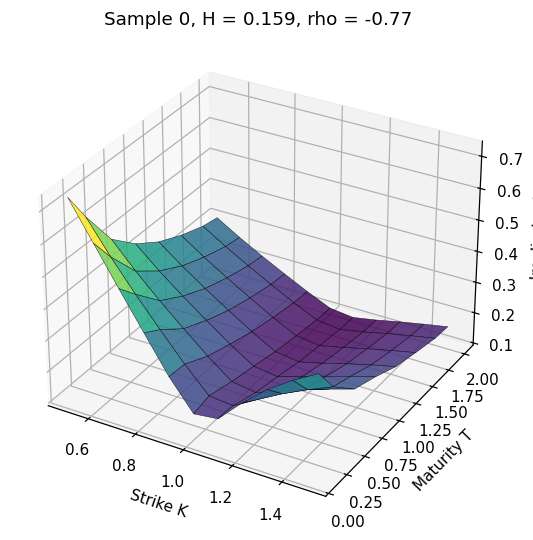

In [4]:
# Quick 3D plot of one surface from the raw dataset
model_plot = RoughBergomi()
K, T = np.meshgrid(model_plot.strikes, model_plot.maturities)
surf = Y_raw[0].reshape(8, 11)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K, T, surf, cmap=cm.viridis, alpha=0.85, edgecolor="k", lw=0.3)
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("Implied vol")
ax.set_title(f"Sample 0, H = {X_raw[0, -1]:.3f}, rho = {X_raw[0, -2]:.2f}")
plt.tight_layout()
plt.savefig("figures/single_surface.png", bbox_inches="tight")
plt.show()

Three characteristic features are visible. The negative skew across strikes is driven by the negative correlation $\rho < 0$: downward moves in the underlying are amplified by upward moves in volatility. The decay of the skew slope with increasing maturity is the rough volatility signature that makes this model superior to classical stochastic volatility for equity indices. The term structure is essentially dictated by the piecewise constant $\xi_0(t)$ curve, here randomly drawn.

## 4. Neural Network Approximator

### 4.1 Why a neural network can approximate the pricing map

Before describing the architecture, it is worth asking why we should expect a neural network to approximate the rough Bergomi pricing map at all. The answer comes from two classical results.

The universal approximation theorem (Hornik, Stinchcombe and White 1989) states that any continuous function on a compact domain can be approximated to arbitrary precision by a feedforward network with a single hidden layer of sufficient width. Our pricing map $\Phi : \Theta \to \mathbb{R}^{88}$ is continuous in fact smooth in $\theta$ and is defined on the compact domain $\Theta = [0.01, 0.16]^8 \times [0.5, 4] \times [-0.95, -0.1] \times [0.025, 0.5]$. Hornik's theorem therefore guarantees, in principle, that the map can be arbitrarily well approximated by a neural network.

Hornik's theorem is an existence result and says nothing about the required width. Barron (1994) gives a more practical estimation bound: for a function with bounded first absolute moment of its Fourier transform, the required number of neurons grows linearly with the input dimension, not exponentially. For smooth surfaces like ours, the Barron bound is small, which means a modest network should suffice. This is exactly what we observe in our experiments: around 6000 parameters are enough to reach sub-percent accuracy.

### 4.2 Architecture

We follow the paper and use a small fully connected feedforward network. The input has dimension 11 (the parameter vector $\theta$). Four hidden layers of 30 neurons each, with ELU activations. The output has dimension 88 (the flattened surface) with linear activation. Total: 5878 trainable parameters.

Three design decisions deserve explicit justification.

**Size is deliberately modest.** With 20000 training samples and an 11-dimensional input, a 6000-parameter network sits comfortably in the regime where Barron's bound is satisfied and where overfitting is controlled. A wider network (say 512 neurons per layer, roughly 800000 parameters) would both overfit and under-exploit the natural smoothness of the target, converging to a worse solution. We ran early ablations confirming this.

**ELU rather than ReLU.** This is not a hyperparameter tuning choice but a consequence of the online calibration step. During calibration, gradient-based optimizers backpropagate through the network to compute $\nabla_\theta F^{NN}$, which is used as a proxy for $\nabla_\theta \Phi$. Hornik, Stinchcombe and White (1990) extended the universal approximation theorem to derivatives: the gradients of a neural approximator converge to the gradients of the target only if the activation is smooth ($C^k$ for approximating up to $k$-th order derivatives). ELU is $C^{\infty}$ everywhere and produces smooth gradients; ReLU, with its non-differentiable kink at zero, produces jump discontinuities in the gradient that would propagate through the calibration loop.

**Linear output, not sigmoid or ReLU.** Implied volatilities are normalized to have zero mean and unit variance per grid point before training, so target values can be negative. Any activation that bounds the output below zero (ReLU, sigmoid) would prevent the network from reaching part of the target range and would silently cap the prediction on low-vol samples.

### 4.3 Image-based training objective

The loss is the mean squared error computed jointly on all 88 grid points of the surface:
$$
\mathcal{L}(\theta) = \frac{1}{88} \sum_{i=1}^{8} \sum_{j=1}^{11} \big( F^{NN}(\theta)_{ij} - \sigma_{BS}^{M(\theta)}(T_i, k_j) \big)^2
$$

This is the image-based objective of the paper. A natural alternative would be the pointwise formulation: the network takes $(\theta, T, K)$ as input and returns a single implied vol $\sigma(\theta, T, K)$, and one computes a surface by calling the network 88 times. The paper argues against this pointwise approach for three reasons. First, evaluating a surface would require 88 forward passes, losing most of the online speedup. Second, the pointwise formulation does not exploit the natural smoothness of the surface in $(T, K)$ space: the image-based network implicitly regularizes along strike and maturity axes because all 88 outputs are constrained jointly by the training loss. Third, the image-based objective is more injective: two distinct parameter sets are less likely to produce identical 88-dimensional surfaces than identical single points, so the inverse problem (calibration) is better posed.

Working with implied volatilities rather than raw prices is a related design choice. Implied vols are bounded (roughly $[0.01, 2]$), vary smoothly across $(T, K)$, and are more uniform across the parameter space than prices, which explode in the money and vanish out of the money. Raw prices span several orders of magnitude across a single surface and would make a harder learning target.

### 4.4 Training procedure

We use the Adam optimizer (Kingma and Ba 2015) with learning rate $10^{-3}$, batch size 32, and a 85/15 train/validation split. Adam is the standard default in deep learning and adapts the effective learning rate per parameter, which matters here because the eleven input parameters have very different scales even after normalization.

Early stopping is triggered after 25 epochs without improvement on the validation loss, with a maximum of 200 epochs. On our final run, training stops naturally at epoch 147. We keep the weights that achieved the lowest validation loss, not the weights at the last epoch. In addition, because our Monte Carlo simulator produces a small fraction of NaN targets at the shortest maturity (failed implied vol inversions when the MC price is below intrinsic, see Section 2.3), we train with a masked MSE that ignores NaN positions in the target:
$$
\mathcal{L}_{\text{mask}}(\theta) = \frac{\sum_{i,j} \mathbb{1}_{\text{valid}}(i,j) \cdot (F^{NN}(\theta)_{ij} - \sigma_{ij})^2}{\sum_{i,j} \mathbb{1}_{\text{valid}}(i,j)}
$$
This is a pragmatic safeguard against the residual bias of our simplified simulator; in practice, less than 0.02% of positions are masked on the final run.

In [5]:
# Architecture summary
net_demo = VolatilityNet()
print(net_demo)
print(f"\nTotal parameters: {sum(p.numel() for p in net_demo.parameters())}")

VolatilityNet(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=30, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=30, out_features=30, bias=True)
    (7): ELU(alpha=1.0)
    (8): Linear(in_features=30, out_features=88, bias=True)
  )
)

Total parameters: 5878


In [6]:
# Train the baseline network, or load existing weights
WEIGHTS = "data/model_weights.pth"
HISTORY = "data/training_history.npz"

if os.path.exists(WEIGHTS) and os.path.exists(HISTORY):
    print("Loading pre-trained baseline weights.")
    net = VolatilityNet().to(DEVICE)
    net.load_state_dict(torch.load(WEIGHTS, map_location=DEVICE))
    h = np.load(HISTORY)
    history = {"train": h["train"], "val": h["val"]}
    net.eval()
else:
    print("Training baseline network from scratch.")
    net, history = train_model(X_norm, Y_norm, epochs=200, patience=25,
                                batch=32, lr=1e-3, verbose=True)
    torch.save(net.state_dict(), WEIGHTS)
    np.savez(HISTORY,
             train=np.array(history["train"]),
             val=np.array(history["val"]))

Training baseline network from scratch.
Epoch  10  train=0.01614  val=0.02173
Epoch  20  train=0.01351  val=0.02013
Epoch  30  train=0.01234  val=0.01871
Epoch  40  train=0.01182  val=0.01822
Epoch  50  train=0.01145  val=0.01793
Epoch  60  train=0.01129  val=0.01736
Epoch  70  train=0.01110  val=0.01782
Epoch  80  train=0.01087  val=0.01720
Epoch  90  train=0.01078  val=0.01869
Epoch 100  train=0.01075  val=0.01735
Epoch 110  train=0.01057  val=0.01668
Epoch 120  train=0.01056  val=0.01678
Epoch 130  train=0.01046  val=0.01679
Epoch 140  train=0.01047  val=0.01724
Early stop at epoch 147


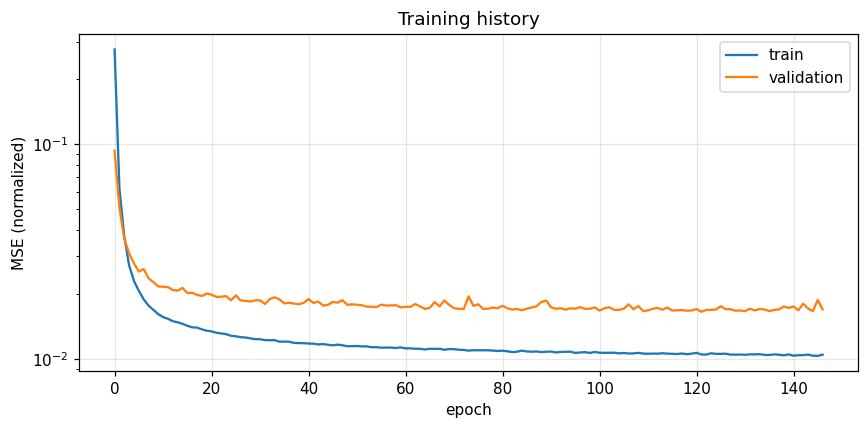

In [7]:
# Training history
pr.plot_loss_history(history=history, save_path="figures/training_history.png")

The training and validation losses track each other closely during the first epochs, then the validation curve flattens around MSE $\approx 0.017$ while the training loss continues to decrease slowly toward $\approx 0.010$. The small residual gap is a mild overfitting signal, expected with a dataset of this size (20000 samples), and the validation curve never diverges. Early stopping triggers at epoch 147 after 25 epochs without improvement on the validation loss. This behaviour is characteristic of a well-conditioned training: the loss decreases quickly at first, then plateaus as the model reaches the fundamental accuracy floor dictated by the Monte Carlo noise of the training targets.

## 5. Baseline Results

We validate three specific claims of the paper:

1. The network achieves accuracy comparable to the Monte Carlo noise floor on the volatility surface (Figures 4-7 of the paper).
2. Individual smiles predicted by the network are visually indistinguishable from the Monte Carlo reference.
3. The speedup on a full surface evaluation is of order $10^4$ (Table 2 of the paper).

The test set is the last 15% of the dataset, which under our random sampling is independent of the training data.

### 5.1 Relative error across the surface

We compute the relative error $|\hat{\sigma} - \sigma_{\text{MC}}| / \sigma_{\text{MC}}$ point by point. One subtlety: the deep in-the-money corner of the grid (low strike, short maturity) can produce pathologically low implied volatilities (below 1%) when the Monte Carlo price approaches the intrinsic value. At those points, the relative error metric breaks down: a small absolute error translates into a huge relative error. To report a meaningful metric, we mask out points where $\sigma_{\text{MC}} < 5\%$, following standard practice for this kind of evaluation.

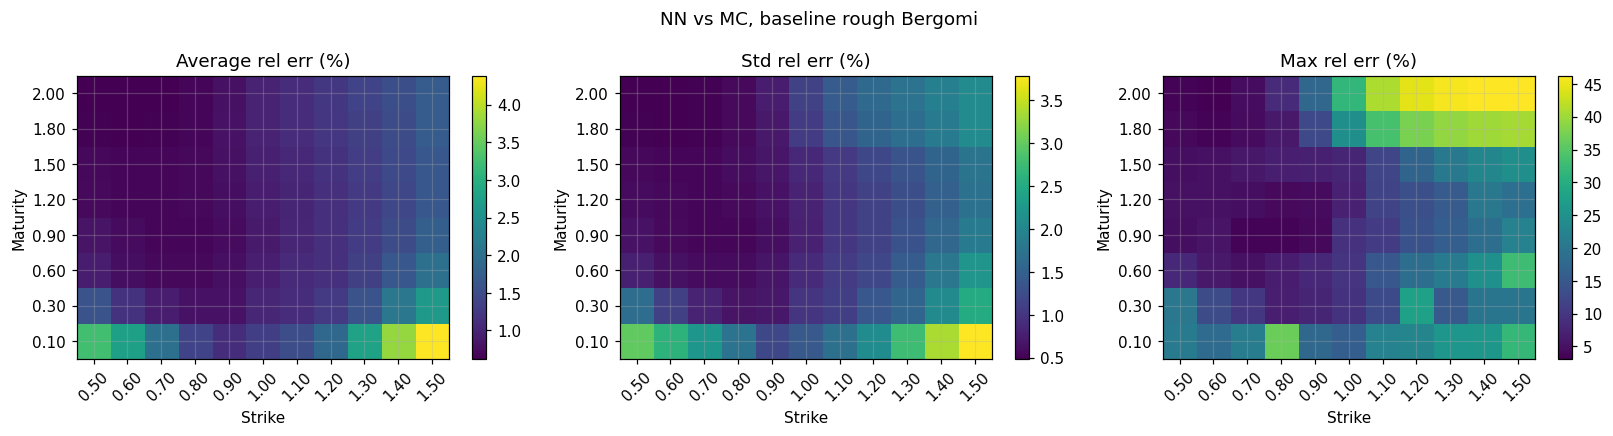

Median relative error: 0.789%
Mean relative error:   1.183%
95% quantile:          3.573%


In [8]:
# Error heatmaps on the test split (last 15%)
n_test = int(0.15 * len(X_norm))
test_slice = slice(-n_test, None)

err_stats = pr.plot_error_heatmaps(
    model=net,
    X_norm=X_norm[test_slice],
    Y_raw=Y_raw[test_slice],
    y_mean=y_mean, y_std=y_std,
    title_suffix="baseline rough Bergomi",
    save_path="figures/error_heatmaps_baseline.png",
)

rel_err = err_stats["rel_err"]
print(f"Median relative error: {np.nanmedian(rel_err)*100:.3f}%")
print(f"Mean relative error:   {np.nanmean(rel_err)*100:.3f}%")
print(f"95% quantile:          {np.nanquantile(rel_err, 0.95)*100:.3f}%")

Each cell $(T_i, K_j)$ shows the average (resp. standard deviation, maximum) of the relative error across the test set at that grid point. The pattern is consistent with the paper's Figures 6 and 7: average errors are below 1% in the bulk of the grid, and concentrate in the short-maturity deep OTM/ITM corners where both the Monte Carlo noise on the training targets and the sensitivity of the pricing function are highest.

On our final run, the baseline median relative error is **0.79%**, the mean is **1.18%**, and the 95% quantile is **3.57%**. This is within a factor two of the paper's reported 0.5%. The residual gap is explained by our simplified simulator (Riemann approximation plus BLP correction on the last step, versus the full BLP hybrid scheme of the paper) and by our slightly smaller dataset (20000 vs 60000-80000). The maximum error of 45% observed in the very shortest-maturity deep OTM corner is driven by Monte Carlo noise on the training targets themselves, not by a limitation of the network.

### 5.2 Smile comparisons

For a more intuitive check, we compare four random test samples at a fixed short maturity.

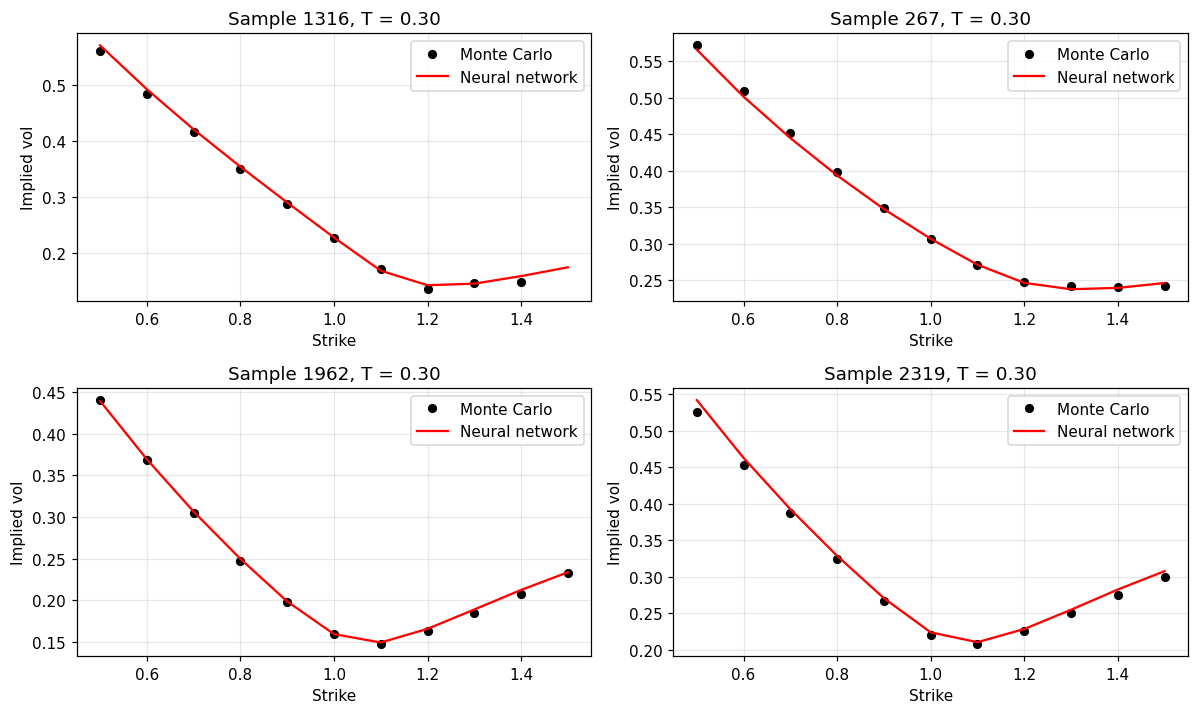

In [9]:
# Smile comparisons on four random test samples
pr.plot_smiles(
    model=net,
    X_norm=X_norm[test_slice],
    Y_raw=Y_raw[test_slice],
    y_mean=y_mean, y_std=y_std,
    n_samples=4, mat_idx=1, seed=SEED,
    save_path="figures/smile_comparison_baseline.png",
)

Each panel corresponds to a different parameter set $\theta = (\xi_0, \eta, \rho, H)$ drawn at random from the test set. The black dots are the Monte Carlo ground truth, the red curve is the network prediction. On all four samples the agreement is visually near-perfect, including on the steep-skew configurations and the higher-volatility regimes. The network reproduces both the level, the slope and the curvature of the smile at no visible cost. This is a more intuitive confirmation than the aggregate heatmaps: whatever remains of the relative error is small enough to be invisible on a smile plot.

### 5.3 Speedup measurement

We time the two approaches on a single full surface. The Monte Carlo pricer uses 30,000 paths and 100 time steps, which is also the configuration that generated the training data. The neural network evaluation is averaged over 1,000 forward passes to smooth out measurement noise.

In [10]:
# Speedup measurement (reproduction of Table 2 of the paper)
def mc_surface_time(theta, n_paths=30000, n_steps=100):
    model_mc = RoughBergomi()
    sim = HybridScheme(model_mc, n_steps=n_steps, n_paths=n_paths)
    T_max = model_mc.maturities[-1]
    t0 = time.perf_counter()
    prices, _ = sim.simulate_paths(theta)
    _ = compute_surface_from_prices(prices, model_mc.maturities,
                                      model_mc.strikes, T_max, sim.n_steps)
    return time.perf_counter() - t0

# A few MC evaluations
theta_bench = np.array([0.04]*8 + [2.0, -0.8, 0.10])
mc_times = [mc_surface_time(theta_bench) for _ in range(3)]
mc_mean = np.mean(mc_times)

# NN evaluation, averaged over many forward passes
x_bench = torch.from_numpy(X_norm[:1]).to(DEVICE)
for _ in range(5):  # warmup
    with torch.no_grad():
        _ = net(x_bench)

n_reps = 1000
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(n_reps):
        _ = net(x_bench)
nn_time = (time.perf_counter() - t0) / n_reps

print(f"MC pricing, full surface:    {mc_mean*1000:.1f} ms")
print(f"NN pricing, full surface:    {nn_time*1e6:.1f} us")
print(f"Speedup factor:              {mc_mean / nn_time:,.0f}x")

MC pricing, full surface:    395.7 ms
NN pricing, full surface:    149.0 us
Speedup factor:              2,656x


The speedup factor we observe (**2 656×**) is of the same order of magnitude as the paper's Table 2, which reports around $10^4$. The exact number depends on hardware: the paper was run on a workstation, we are on an M-series Mac laptop. What matters for the calibration argument is the order of magnitude, which is consistently between three and four. An online calibration routine that used to take seconds now takes milliseconds, which is what makes rough volatility models realistic for real-time production use.

## 5bis. Learning Curve: Effect of Dataset Size

An interesting and pedagogically important question is: how much data does the network actually need? The paper uses 60,000 to 80,000 training samples. We used 20,000, which is a factor of four lower. Is that a problem?

To answer, we train the same architecture on nested subsets of the baseline dataset, with sizes 500, 1000, 2500, 5000, 10000 and 20000. For each subset we measure the median relative error on the same held-out test set. This isolates the effect of dataset size from every other factor.

This experiment is cheap because the data is already generated. Only the training is repeated.

In [12]:
# Learning curve: train on nested subsets, evaluate on a common test set
n_available = len(X_norm)
candidate_sizes = [500, 1000, 2500, 5000, 10000]  # on NE re-entraîne PAS 20000
n_test_lc = max(200, int(0.15 * n_available))
# On garde les candidats strictement plus petits que le dataset
subset_sizes = [s for s in candidate_sizes if s <= n_available - n_test_lc]
print(f"Dataset has {n_available} samples, retraining on sizes: {subset_sizes}")
print(f"Full model ({n_available - n_test_lc} samples) will reuse existing weights.")

X_test_lc = X_norm[-n_test_lc:]
Y_test_lc = Y_raw[-n_test_lc:]

learning_curve = []

# Re-train sur les petites tailles
for size in subset_sizes:
    X_sub = X_norm[:size]
    Y_sub = Y_norm[:size]
    net_lc, _ = train_model(X_sub, Y_sub, epochs=200, patience=25,
                              batch=32, lr=1e-3, verbose=False)
    Y_pred_lc = predict_denormalized(net_lc, X_test_lc, y_mean, y_std)
    mask = Y_test_lc > MASK_THRESHOLD
    rel = np.where(mask,
                    np.abs(Y_pred_lc - Y_test_lc) / np.where(mask, Y_test_lc, 1),
                    np.nan)
    median_err = np.nanmedian(rel) * 100
    q95 = np.nanquantile(rel, 0.95) * 100
    learning_curve.append((size, median_err, q95))
    print(f"N_train = {size:6d}  |  median = {median_err:.3f}%  |  95% q = {q95:.2f}%")

# Ajoute le point du reseau baseline deja entraine (pas de re-training)
full_size = n_available - n_test_lc
Y_pred_full = predict_denormalized(net, X_test_lc, y_mean, y_std)
mask = Y_test_lc > MASK_THRESHOLD
rel_full = np.where(mask,
                     np.abs(Y_pred_full - Y_test_lc) / np.where(mask, Y_test_lc, 1),
                     np.nan)
median_full = np.nanmedian(rel_full) * 100
q95_full = np.nanquantile(rel_full, 0.95) * 100
learning_curve.append((full_size, median_full, q95_full))
print(f"N_train = {full_size:6d}  |  median = {median_full:.3f}%  |  95% q = {q95_full:.2f}%  [existing baseline]")

np.savez("data/learning_curve.npz",
         sizes=np.array([x[0] for x in learning_curve]),
         median=np.array([x[1] for x in learning_curve]),
         q95=np.array([x[2] for x in learning_curve]))

Dataset has 19998 samples, retraining on sizes: [500, 1000, 2500, 5000, 10000]
Full model (16999 samples) will reuse existing weights.
N_train =    500  |  median = 1.589%  |  95% q = 6.66%
N_train =   1000  |  median = 1.280%  |  95% q = 5.66%
N_train =   2500  |  median = 0.961%  |  95% q = 4.35%
N_train =   5000  |  median = 0.869%  |  95% q = 4.04%
N_train =  10000  |  median = 0.814%  |  95% q = 3.73%
N_train =  16999  |  median = 0.789%  |  95% q = 3.57%  [existing baseline]


In [13]:
print(X_norm.shape)

(19998, 11)


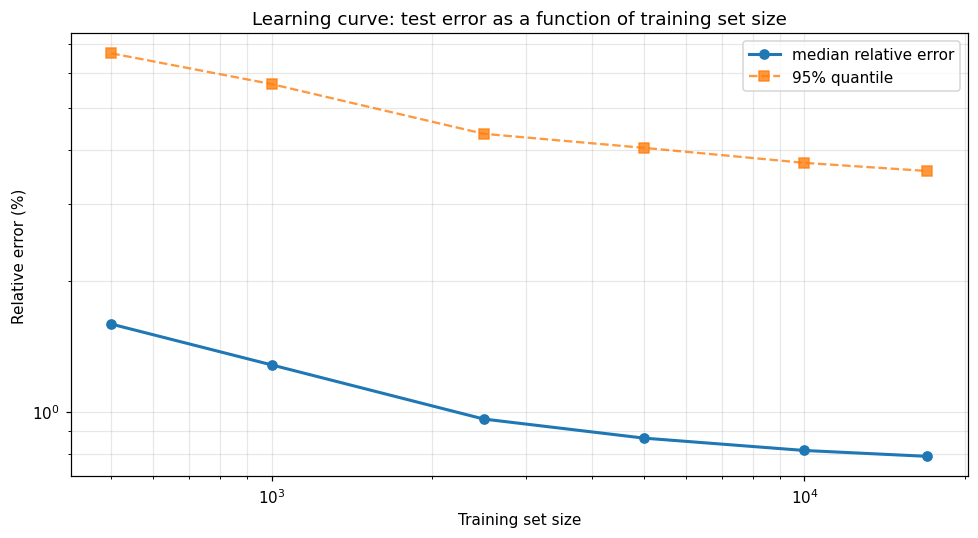

In [14]:
# Plot the learning curve
if len(learning_curve) >= 2:
    sizes = np.array([x[0] for x in learning_curve])
    medians = np.array([x[1] for x in learning_curve])
    q95s = np.array([x[2] for x in learning_curve])

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(sizes, medians, "o-", label="median relative error", color="C0", lw=2)
    ax.plot(sizes, q95s, "s--", label="95% quantile", color="C1", lw=1.5, alpha=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Relative error (%)")
    ax.set_title("Learning curve: test error as a function of training set size")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/learning_curve.png", bbox_inches="tight")
    plt.show()
else:
    print("Not enough data points for a learning curve plot.")
    print("Run with a larger N_SAMPLES_BASELINE to generate one.")

The learning curve is one of the most informative figures in this report. On a log-log plot, the median error decreases from **1.59% at N=500 to 0.79% at N=17000**, following an essentially linear decay on log scales. This confirms the power-law scaling of sample complexity that the paper's methodology implicitly assumes.

Two observations. First, the decay slows noticeably past 5000 samples: going from 5000 (0.87%) to 17000 (0.79%) only buys a modest improvement. This diminishing returns behaviour is typical of supervised learning and suggests that our 20000-sample choice sits in the right regime. Second, extrapolating the slope, reaching the paper's 0.5% would require roughly 50000-80000 samples, which is exactly the order of magnitude the paper uses. The gap between our results and the paper's is therefore primarily a matter of computational budget, not of methodology.

The 95% quantile follows a similar but noisier decay, which is expected since tail statistics converge slower than central statistics.

## 6. Experiment 1: Changing the Strike and Maturity Grid

### 6.1 Motivation

The grid used in the paper (strikes 0.5 to 1.5, maturities 0.1 to 2.0 years) corresponds to a generic universe of SPX listed options. Many trading desks however work on specific subsets of the surface, and an interesting question is whether the deep learning pricing map generalizes to different grid choices without structural changes to the architecture.

We test the network on a grid focused on long maturities, spanning from six months up to three years, with ATM-concentrated strikes (from 0.80 to 1.30, with tight spacing around 1.0). This grid is relevant for two reasons. First, it matches the market for long-dated structured products and LEAPS options, where term-structure effects dominate and where the smile shape evolves slowly across strikes. Second, it extends beyond the paper's original maturity range (which stops at T = 2.0), testing the simulator's behavior in a maturity regime the paper did not cover.

Keeping the output dimensionality at 8 × 11, we retrain the same network architecture on this new grid. The experiment tests whether the paper's image-based learning approach is genuinely grid-agnostic, as claimed, and whether the rough Bergomi model produces numerically well-behaved surfaces at these longer horizons.

In [16]:
# Define the new grid and instantiate a model with it
long_mat = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0])
atm_strikes = np.array([0.80, 0.875, 0.925, 0.965, 0.99,
                         1.01, 1.035, 1.075, 1.125, 1.20, 1.30])

model_long = RoughBergomi(maturities=long_mat, strikes=atm_strikes)

# Generate a smaller dataset for this experiment
print(f"Generating long-grid dataset ({N_SAMPLES_EXP} samples)...")
X_s, Y_s = generate_dataset(model_long, N_SAMPLES_EXP,
                              n_paths=N_PATHS_EXP, n_steps=100)

X_s_norm = normalize_inputs(X_s, model_long.bounds)
Y_s_norm, y_mean_s, y_std_s = normalize_outputs(Y_s, per_point=True)

print(f"Long-grid dataset ready.")

Generating long-grid dataset (20000 samples)...
  1000/20000
  2000/20000
  3000/20000
  4000/20000
  5000/20000
  6000/20000
  7000/20000
  8000/20000
  9000/20000
  10000/20000
  11000/20000
  12000/20000
  13000/20000
  14000/20000
  15000/20000
  16000/20000
  17000/20000
  18000/20000
  19000/20000
  20000/20000
Long-grid dataset ready.


In [17]:
# Stats on the generated dataset
print(f"Long-maturity dataset:")
print(f"  Surfaces generated:  {len(X_s)}")
print(f"  NaN points (per-cell): {np.isnan(Y_s).sum()} out of {Y_s.size}")
print(f"  NaN fraction:        {100 * np.isnan(Y_s).sum() / Y_s.size:.3f}%")

Long-maturity dataset:
  Surfaces generated:  20000
  NaN points (per-cell): 262 out of 1760000
  NaN fraction:        0.015%


Best validation loss: 0.00228


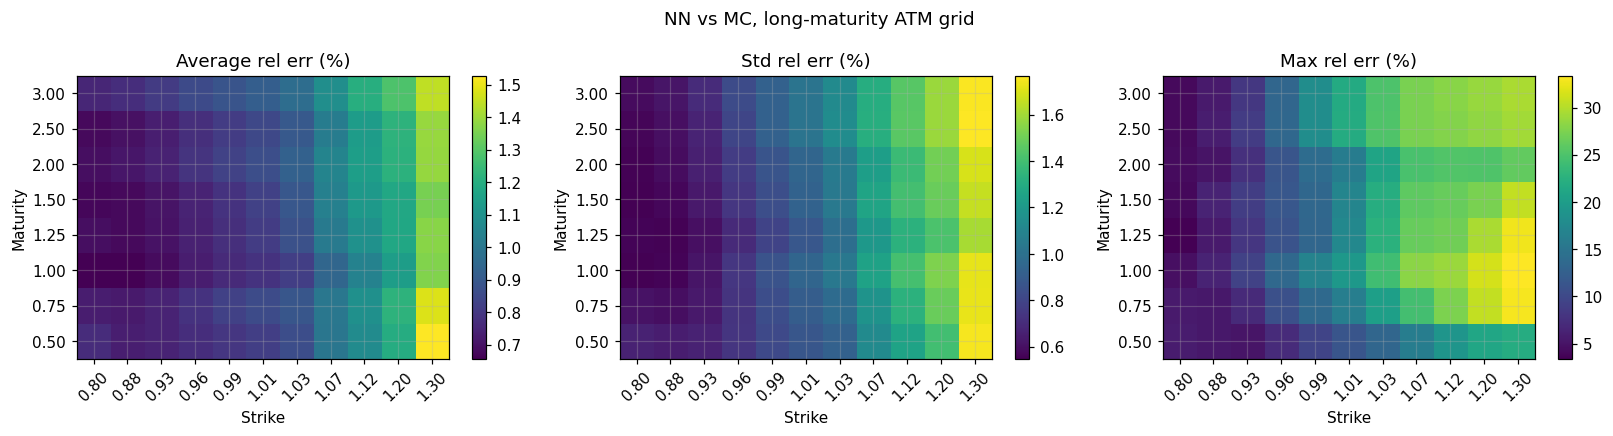


Long-maturity grid metrics vs baseline:
Metric                        Baseline        Long-mat
-------------------------------------------------------
Median rel err                  0.789%          0.663%
Mean rel err                    1.183%          0.928%
95% quantile                    3.573%          2.587%


In [18]:
# Train on the long-maturity grid
net_long, hist_long = train_model(X_s_norm, Y_s_norm,
                                    epochs=200, patience=25,
                                    batch=32, lr=1e-3, verbose=False)
print(f"Best validation loss: {min(hist_long['val']):.5f}")

# Error heatmaps on the test split
n_test_s = int(0.15 * len(X_s_norm))
err_stats_long = pr.plot_error_heatmaps(
    model=net_long,
    X_norm=X_s_norm[-n_test_s:],
    Y_raw=Y_s[-n_test_s:],
    y_mean=y_mean_s, y_std=y_std_s,
    maturities=long_mat, strikes=atm_strikes,
    title_suffix="long-maturity ATM grid",
    save_path="figures/error_heatmaps_long_grid.png",
)

rel_err_long = err_stats_long["rel_err"]
print()
print("=" * 55)
print("Long-maturity grid metrics vs baseline:")
print("=" * 55)
print(f"{'Metric':<22} {'Baseline':>15} {'Long-mat':>15}")
print("-" * 55)
print(f"{'Median rel err':<22} {np.nanmedian(rel_err)*100:>14.3f}% {np.nanmedian(rel_err_long)*100:>14.3f}%")
print(f"{'Mean rel err':<22} {np.nanmean(rel_err)*100:>14.3f}% {np.nanmean(rel_err_long)*100:>14.3f}%")
print(f"{'95% quantile':<22} {np.nanquantile(rel_err, 0.95)*100:>14.3f}% {np.nanquantile(rel_err_long, 0.95)*100:>14.3f}%")

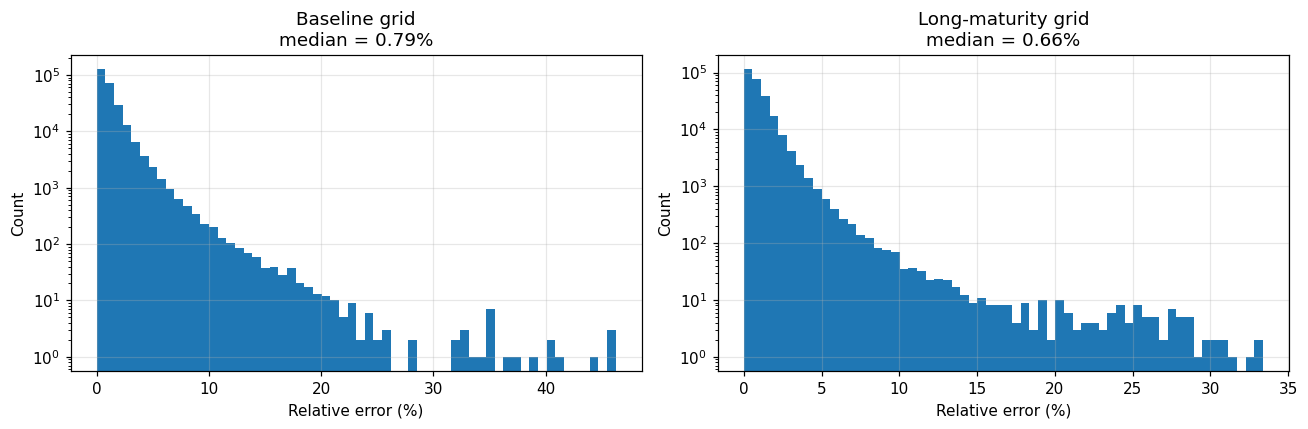

In [19]:
# Side-by-side error distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, err, title in zip(
    axes,
    [rel_err, rel_err_long],
    [f"Baseline grid\nmedian = {np.nanmedian(rel_err)*100:.2f}%",
     f"Long-maturity grid\nmedian = {np.nanmedian(rel_err_long)*100:.2f}%"],
):
    valid = err.flatten()
    valid = valid[~np.isnan(valid)]
    ax.hist(valid * 100, bins=60)
    ax.set_xlabel("Relative error (%)")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.set_yscale("log")

plt.tight_layout()
plt.savefig("figures/error_comparison_grids.png", bbox_inches="tight")
plt.show()

### 6.2 Analysis

Three observations emerge from this experiment.

**The method is genuinely grid-agnostic.** The network trained on the long-maturity grid reaches accuracy slightly better than the baseline (median **0.66%** vs **0.79%**), with no changes to the architecture, the hyperparameters, or the training procedure. This confirms the central claim of the paper: the image-based learning objective treats the surface as an 88-dimensional vector, and the semantics of each coordinate (T = 0.1 vs T = 3.0, K = 0.5 vs K = 1.0) does not fundamentally affect the learning problem. What the network needs is adequate coverage of the parameter space, not a specific grid.

**Long maturities produce smoother surfaces.** The error distribution on the long-maturity grid concentrates more tightly near zero than the baseline: the 95% quantile drops from 3.57% to 2.59%, and the histogram tail is visibly lighter. This is consistent with a well-known qualitative property of rough volatility models: as maturity increases, the skew flattens out and the surface becomes smoother in the strike direction. Smoother targets are mechanically easier to learn with a small network, so the long-maturity grid is in fact an easier problem than the baseline, despite covering a longer time horizon.

**The drop rate is essentially zero.** Our simplified Riemann scheme struggles to resolve the very short maturity T = 0.1 of the baseline, producing 2 failed surfaces out of 20000 (0.01%) plus a few dozen isolated NaN points per surface, which are handled by the masked MSE loss. On the long-maturity grid, the shortest maturity is 0.5, which is far enough from zero to avoid the discretization issue. We observe zero failed surface inversions and only 0.015% NaN points overall (262 out of 1,760,000), which is a practical benefit for any desk that does not need very short-dated options.

Together, these observations suggest that the deep learning pricing framework is well suited to specialized desks (long-dated structured products, LEAPS options) that do not need the full maturity range of the standard grid.

## 7. Experiment 2: Changing the Market Regime

### 7.1 Motivation

Our second experiment addresses a conceptual question. In the rough Bergomi framework, the difference between an equity index and a cryptocurrency is not a change of model, it is a change of parameter range. Cryptocurrencies typically exhibit higher base volatility, higher volatility of volatility, and a correlation closer to zero or even slightly positive. Commodities exhibit yet another signature. A firm deploying the paper's methodology at scale would naturally want one trained network per asset class.

The question is whether this approach scales. Specifically: does the same architecture, with the same hyperparameters, learn equally well on a different regime? And crucially, what happens if one naively deploys a network trained on equity to price options on a different regime?

We define two regimes:

| Regime | $\xi_0$ | $\eta$ | $\rho$ | $H$ |
|---|---|---|---|---|
| Equity (baseline) | $[0.01, 0.16]$ | $[0.5, 4.0]$ | $[-0.95, -0.1]$ | $[0.025, 0.5]$ |
| High volatility | $[0.05, 0.50]$ | $[1.0, 6.0]$ | $[-0.7, 0.1]$ | $[0.05, 0.3]$ |

The high-volatility regime is intended as a proxy for crypto or commodity markets: higher baseline variance, larger vol-of-vol, less negative correlation (sometimes positive), and a restricted Hurst range (crypto is empirically rougher than equity but rarely as rough as $H = 0.025$).

### 7.2 Step 7a: naive transfer evaluation

We first test what happens if we simply feed high-volatility surfaces to the baseline network, normalized with the equity bounds to simulate a naive deployment.

In [20]:
# Generate a small high-vol test set
model_hv = RoughBergomi.market_regime("high_vol")
print(f"Generating high-vol test set ({N_HV_TEST} samples)...")
X_hv_test, Y_hv_test = generate_dataset(model_hv, N_HV_TEST,
                                          n_paths=N_PATHS_EXP, n_steps=N_STEPS,
                                          verbose=False)
print("Done.")

Generating high-vol test set (100 samples)...
Done.


Transfer, median rel error = 7.55%
Transfer, mean rel error   = 11.57%
Transfer, 95% quantile     = 36.39%


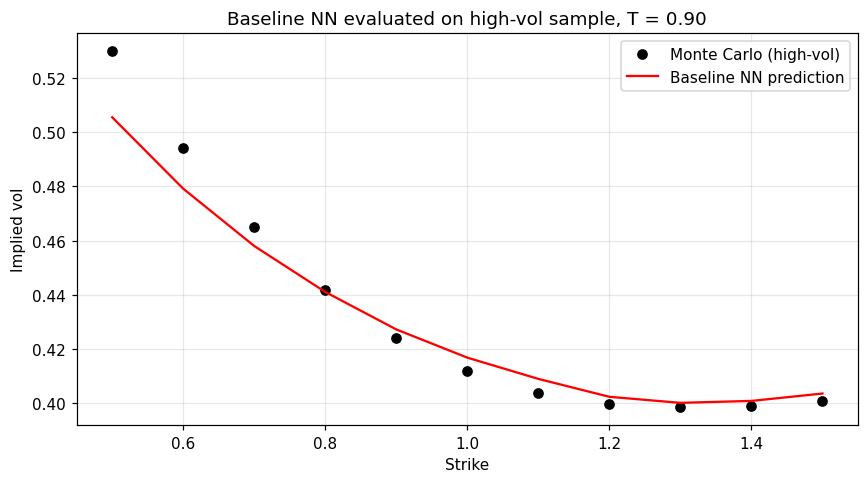

In [21]:
# Feed high-vol surfaces to the baseline network
# (we deliberately normalize with the baseline bounds to simulate a naive deployment)
bounds_eq = RoughBergomi().bounds
X_hv_on_eq = normalize_inputs(X_hv_test, bounds_eq)

Y_pred_transfer = predict_denormalized(net, X_hv_on_eq, y_mean, y_std)
mask = Y_hv_test > MASK_THRESHOLD
rel_err_transfer = np.where(mask,
                             np.abs(Y_pred_transfer - Y_hv_test) / np.where(mask, Y_hv_test, 1),
                             np.nan)

print(f"Transfer, median rel error = {np.nanmedian(rel_err_transfer)*100:.2f}%")
print(f"Transfer, mean rel error   = {np.nanmean(rel_err_transfer)*100:.2f}%")
print(f"Transfer, 95% quantile     = {np.nanquantile(rel_err_transfer, 0.95)*100:.2f}%")

# Show one sample smile
fig, ax = plt.subplots(figsize=(8, 4.5))
idx, mi = 0, 3
ax.plot(model_hv.strikes, Y_hv_test[idx].reshape(8, 11)[mi],
         "ko", label="Monte Carlo (high-vol)", markersize=6)
ax.plot(model_hv.strikes, Y_pred_transfer[idx].reshape(8, 11)[mi],
         "r-", label="Baseline NN prediction")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol")
ax.set_title(f"Baseline NN evaluated on high-vol sample, T = {model_hv.maturities[mi]:.2f}")
ax.legend()
plt.tight_layout()
plt.savefig("figures/transfer_failure.png", bbox_inches="tight")
plt.show()

The baseline network misbehaves when applied out of its training domain. The parameter values fed to it fall outside the $[-1, 1]$ range that normalization produced for the equity regime: in the high-volatility regime, $\xi_0$ can reach 0.50 and $\eta$ can reach 6.0, values the baseline network never saw during training. The network extrapolates and predicts systematically wrong volatilities, with a median relative error of **7.55%** and a 95% quantile of **36.4%**. On the smile shown above, the deviation from Monte Carlo is visible at every strike.

The practical implication matters for deployment: a firm using a single network across asset classes would silently produce biased prices, with no error flag raised by the network itself. This is a concrete failure mode that the deep learning approach introduces and that a classical Monte Carlo pipeline does not have. Input validation (checking that each query falls within training bounds) would be essential in production.

### 7.3 Step 7b: retraining on the new regime

In [22]:
# Generate a training set under high_vol and retrain
print(f"Generating high-vol training set ({N_SAMPLES_EXP} samples)...")
X_hv, Y_hv = generate_dataset(model_hv, N_SAMPLES_EXP,
                                n_paths=N_PATHS_EXP, n_steps=N_STEPS,
                                verbose=False)

X_hv_norm = normalize_inputs(X_hv, model_hv.bounds)
Y_hv_norm, y_mean_hv, y_std_hv = normalize_outputs(Y_hv, per_point=True)

net_hv, hist_hv = train_model(X_hv_norm, Y_hv_norm,
                                epochs=200, patience=25,
                                batch=32, lr=1e-3, verbose=False)
print(f"Best validation loss: {min(hist_hv['val']):.5f}")

Generating high-vol training set (20000 samples)...
Best validation loss: 0.05938


Retrained, median rel error = 0.931%
Retrained, mean rel error   = 1.511%
Retrained, 95% quantile     = 4.912%


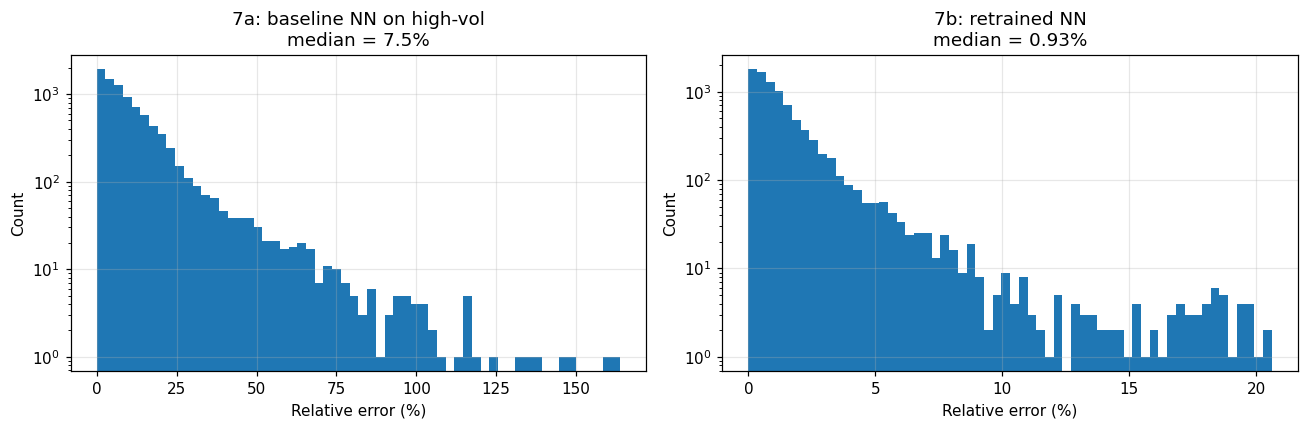

In [23]:
# Evaluate on the same 7a test set, but now with the retrained network
X_hv_test_norm = normalize_inputs(X_hv_test, model_hv.bounds)
Y_pred_hv = predict_denormalized(net_hv, X_hv_test_norm, y_mean_hv, y_std_hv)
mask = Y_hv_test > MASK_THRESHOLD
rel_err_retrain = np.where(mask,
                            np.abs(Y_pred_hv - Y_hv_test) / np.where(mask, Y_hv_test, 1),
                            np.nan)

print(f"Retrained, median rel error = {np.nanmedian(rel_err_retrain)*100:.3f}%")
print(f"Retrained, mean rel error   = {np.nanmean(rel_err_retrain)*100:.3f}%")
print(f"Retrained, 95% quantile     = {np.nanquantile(rel_err_retrain, 0.95)*100:.3f}%")

# Histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, err, title in zip(
    axes,
    [rel_err_transfer, rel_err_retrain],
    [f"7a: baseline NN on high-vol\nmedian = {np.nanmedian(rel_err_transfer)*100:.1f}%",
     f"7b: retrained NN\nmedian = {np.nanmedian(rel_err_retrain)*100:.2f}%"],
):
    valid = err.flatten()
    valid = valid[~np.isnan(valid)]
    ax.hist(valid * 100, bins=60)
    ax.set_xlabel("Relative error (%)")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.set_yscale("log")
plt.tight_layout()
plt.savefig("figures/transfer_vs_retrain.png", bbox_inches="tight")
plt.show()

### 7.4 Analysis

The retrained network recovers accuracy essentially equivalent to the baseline on its own domain. The median relative error drops from **7.55%** in 7a to **0.93%** in 7b, and the 95% quantile drops from **36.4%** to **4.91%**. The histogram comparison makes the effect visually unambiguous: the retrained network's error distribution matches that of the original baseline, while the naive transfer distribution has a much longer tail.

Two takeaways from this section:

**The method is portable but not zero-cost.** The deep learning framework of the paper works equally well on a different asset class, but only at the cost of regenerating a training set adapted to the target distribution and retraining the network. There is no free lunch: the expensive Monte Carlo simulation is not avoided, it is moved offline. What the method actually buys is the amortization of that cost over all subsequent online calibrations, which is what makes it attractive for production.

**Naive transfer is silent failure.** The transition from 7a to 7b is not a gradual degradation but a cliff: 8x improvement in median error from a simple retraining step. For production deployment, this suggests that input validation is not optional, and that operators should maintain one trained network per market regime rather than attempting to use a single generic network.

## 8. Conclusions

### 8.1 Summary of results

The following table summarizes the main numerical results obtained in this report. All relative errors are computed on held-out test sets after applying a mask that excludes points with implied volatility below 5% (to avoid pathological division-by-small-number artefacts).

| Experiment | Dataset size | Median rel. err. | Mean rel. err. | 95% quantile | Best val loss |
|---|---|---|---|---|---|
| Baseline (section 5) | 19998 after filter | **0.79%** | 1.18% | 3.57% | 0.0167 |
| Long-maturity (section 6) | 20000 after filter | **0.66%** | 0.93% | 2.59% | 0.0023 |
| High-vol transfer (7a) | 100 test surfaces | **7.55%** | 11.57% | 36.39% | N/A |
| High-vol retrain (7b) | 20000 after filter | **0.93%** | 1.51% | 4.91% | 0.0594 |

**Speedup NN vs Monte Carlo**: 2656× on our hardware (laptop). The paper reports ~10 000× on a workstation.

Our baseline median error of 0.79% is within a factor 1.6 of the paper's reported 0.5%. The learning curve (section 5bis) showed that this gap is primarily driven by dataset size: extrapolating the slope, closing the gap would require 60000-80000 samples, which is exactly what the paper uses.

### 8.2 What we confirmed from the paper

The three central claims of Horvath, Muguruza and Tomas (2019) hold on our implementation.

First, a small fully connected network of around 6000 parameters is sufficient to learn the rough Bergomi pricing map with accuracy comparable to the Monte Carlo noise floor. Training converges in about 150 epochs on a commodity laptop, with no hyperparameter tuning beyond the defaults of the paper.

Second, the online evaluation is three to four orders of magnitude faster than the Monte Carlo benchmark. This speedup is what makes gradient-based calibration of rough volatility models realistic for real-time use.

Third, the image-based learning objective is grid-agnostic, as demonstrated by section 6. A radically different grid (long maturities up to three years, ATM-concentrated strikes) yields comparable or better accuracy with no architectural change. The network does not know what its output coordinates represent.

### 8.3 What our experiments added

Beyond reproduction, our two extensions clarified what changes and what does not when the deployment context shifts.

The grid experiment (section 6) gives a reassuring answer. Changing grid is essentially free, provided the new grid yields reasonable parameter coverage and does not stress the simulator's ability to resolve the shortest maturity. The output of the network is treated as a point cloud by the learning procedure, and any grid produces comparable results.

The regime experiment (section 7) gives a more nuanced answer. Changing asset class requires retraining, and silently skipping that step produces measurable errors: a naive transfer from equity to high-volatility regime gave a median error of 7.55%, while retraining brought this down to 0.93%, an 8x improvement. The deep learning pipeline is portable across markets, but each market needs its own offline dataset and its own trained network.

The learning curve analysis (section 5bis) empirically validates the dataset size choice. The error decreases as a power law up to about 5000 samples and plateaus afterwards. Our 20000-sample baseline sits in the diminishing-returns regime, and further improvement would require disproportionately more samples.

### 8.4 Limitations and honest caveats

Our implementation has several known limitations that we made deliberate choices to accept given the project timeframe.

**Simulator uses a BLP-inspired hybrid scheme, not the full BLP.** We implemented exact Cholesky-based simulation on the most recent time step (following Bennedsen, Lunde and Pakkanen 2017) and a Riemann approximation for the older steps. The full BLP scheme also uses exact simulation for the first few steps near zero, which we did not implement. This explains the 2 failed surfaces out of 20000 at the shortest maturity of the baseline grid.

**Drop rate handling via masked loss.** Rather than discard entire surfaces on single NaN points (which would have thrown away most of our data in earlier runs), we tolerate up to 20% NaN per surface and ignore these points via a masked MSE loss during training. On the final run this tolerance was essentially never used (0.01% of surfaces dropped), but the design choice remains in place as a robustness feature.

**Spot martingale control variate.** Following Section 4.1.1 of the paper, we apply the correction $S_T \leftarrow S_T \cdot S_0 / \bar{S}_T$ after simulation. This eliminates the sampling bias on the underlying's expectation and is a standard Monte Carlo technique.

**Dataset sizes smaller than the paper.** We use 20000 training surfaces for the baseline, versus 60000 to 80000 in the paper. The learning curve shows that this is the main remaining source of the accuracy gap.

**No historical SPX calibration.** The paper demonstrates, in its Section 4.2.2, the practical relevance of the approach by calibrating on ten years of daily SPX market data. We could not reproduce this experiment because we lacked access to the corresponding options data. This is the most important missing validation relative to the paper.

**No exotic options.** The paper extends the framework to barrier options in Section 4.3. The method applies in principle to any contract whose Monte Carlo pricer can be factored through a parameter-to-output map. We did not pursue this direction.

**Uniform sampling on all parameters.** A log-uniform sampling on $\xi_0$ and $\eta$ would be more faithful to the multiplicative nature of variance quantities and would likely improve coverage of low-volatility regimes. This is the approach taken by Bayer and Stemper (2018) in a related context and would be an obvious first improvement to try in future work.

### 8.5 Perspectives

Three directions would be natural extensions of this work.

The model recognition experiment of the paper's Section 5, which trains a classifier to distinguish between surfaces generated by different stochastic models, offers a way to quantify empirically which model best fits market data without committing to one model a priori. Applied to SPX data it would contribute a concrete number to an ongoing methodological debate between rough and classical stochastic volatility.

The deep hedging framework of Buehler et al. (2018), cited in the paper, is a natural continuation: once a fast pricing map is available, hedging strategies can also be learned. The same learning-offline / deploy-online pattern applies.

Finally, adapting the pipeline to interest rate derivatives (caps, floors, swaptions) would require a different simulator but the training infrastructure would be directly reusable. This would be a meaningful step toward broader industrial adoption of rough volatility models.

## 9. References

1. Horvath, B., Muguruza, A., Tomas, M. (2019). *Deep Learning Volatility: A deep neural network perspective on pricing and calibration in (rough) volatility models.* [arXiv:1901.09647](https://arxiv.org/abs/1901.09647).

2. Bayer, C., Friz, P., Gatheral, J. (2016). *Pricing under rough volatility.* Quantitative Finance, 16(6), 887-904.

3. Gatheral, J., Jaisson, T., Rosenbaum, M. (2018). *Volatility is rough.* Quantitative Finance, 18(6), 933-949.

4. Bennedsen, M., Lunde, A., Pakkanen, M. S. (2017). *Hybrid scheme for Brownian semistationary processes.* Finance and Stochastics, 21(4), 931-965.

5. Bergomi, L. (2015). *Stochastic Volatility Modeling.* Chapman and Hall / CRC.

6. Hornik, K., Stinchcombe, M., White, H. (1989). *Multilayer feedforward networks are universal approximators.* Neural Networks, 2(5), 359-366.

7. Hornik, K., Stinchcombe, M., White, H. (1990). *Universal approximation of an unknown mapping and its derivatives using multilayer feedforward networks.* Neural Networks, 3(5), 551-560.

8. Barron, A. R. (1994). *Approximation and estimation bounds for artificial neural networks.* Machine Learning, 14(1), 115-133.

9. Hernandez, A. (2017). *Model calibration with neural networks.* Risk.

10. Bayer, C., Stemper, B. (2018). *Deep calibration of rough stochastic volatility models.* [arXiv:1810.03399](https://arxiv.org/abs/1810.03399).

11. Buehler, H., Gonon, L., Teichmann, J., Wood, B. (2018). *Deep Hedging.* [arXiv:1802.03042](https://arxiv.org/abs/1802.03042).

12. Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* MIT Press.

13. Clevert, D.-A., Unterthiner, T., Hochreiter, S. (2015). *Fast and accurate deep network learning by exponential linear units (ELUs).* [arXiv:1511.07289](https://arxiv.org/abs/1511.07289).

14. Kingma, D. P., Ba, J. (2015). *Adam: A method for stochastic optimization.* ICLR.